In [1]:
"""
Johannes Gehrig APR 2025

Creates the grids for Topo, (sed), Moho, LAB and RHP needed for the 3d modeling

IN ANTARCTICA
"""

'\nJohannes Gehrig APR 2025\n\nCreates the grids for Topo, (sed), Moho, LAB and RHP needed for the 3d modeling\n\nIN ANTARCTICA\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyproj import Proj
import pickle
from matplotlib.colors import  TwoSlopeNorm
from matplotlib.patches import Rectangle
import xarray as xr
from scipy.interpolate import griddata

In [3]:
km = 1000 # multiplicative factor for m-km conversion
path_topo = "INPUT_DATA_DEMO/Bedmachine/BedMachineAntarctica-v3.nc"
modelno = 3
path_moho = "INPUT_DATA_DEMO/Moho_LAB_Antarctica_PAPPA/model"+str(modelno)+"-Moho.xyz" 
path_lab = "INPUT_DATA_DEMO/Moho_LAB_Antarctica_PAPPA/model"+str(modelno)+"-LAB.xyz"

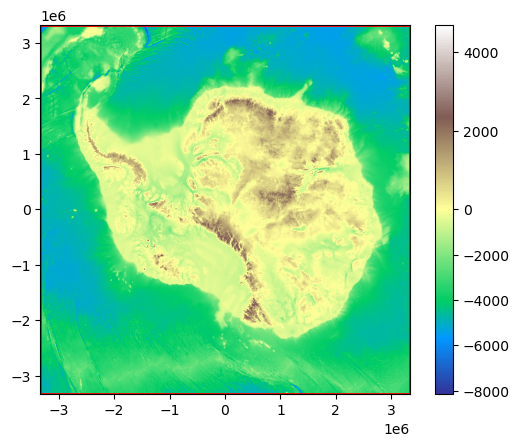

In [4]:
'''
load topo data either from pickle file or netcdf -> https://nsidc.org/data/nsidc-0756/versions/3
Spatial Resolution: 500 m 500 m
Spatial Reference System(s): WGS 84 / Antarctic Polar StereographicEPSG:3031
Spatial Coverage: N:-53S:-90E:180W:-180
'''


default_topo = np.nan # default height
grid_size_topo = 5000 # downsampling resolution in x/y

try:
    with open('output/grid_topo_ANT.pickle', 'rb') as handle:
        grid_topo, xi_topo, yi_topo ,rect_x,rect_y,rect_width,rect_height = pickle.load(handle)
except:
    print("no data found - calculating new grid")

    bedmachine = xr.open_dataset(path_topo)
    #print(dataset)
    topo_bed = bedmachine["bed"]
    #print(topo_bed)
    #topo_bed.x, topo_bed.y, topo_bed
    x_new = np.linspace(np.min(topo_bed.x), np.max(topo_bed.x), grid_size_topo)
    y_new = np.linspace(np.max(topo_bed.y), np.min(topo_bed.y), grid_size_topo)
    xi_topo, yi_topo = np.meshgrid(x_new, y_new)
    

    rect_x = np.min(x_new)
    rect_y = np.min(y_new)
    rect_width = np.max(x_new) - np.min(x_new)
    rect_height = np.max(y_new) - np.min(y_new)

    grid_topo = topo_bed.interp(x=x_new, y=y_new, method="linear").values

    with open('output/grid_topo_ANT.pickle', 'wb') as handle:
        pickle.dump([grid_topo, xi_topo, yi_topo ,rect_x,rect_y,rect_width,rect_height], handle, protocol=pickle.HIGHEST_PROTOCOL)


rect = Rectangle((rect_x, rect_y), rect_width, rect_height, linewidth=2, edgecolor='r', facecolor='none') # draw rectangle around grid extent
plt.gca().add_patch(rect)
divnorm = TwoSlopeNorm(vmin=np.nanmin(grid_topo), vcenter=0., vmax=np.nanmax(grid_topo))
plt.imshow(grid_topo, extent=[np.min(xi_topo), np.max(xi_topo), np.min(yi_topo), np.max(yi_topo)], cmap=plt.cm.terrain, norm=divnorm)
plt.colorbar()

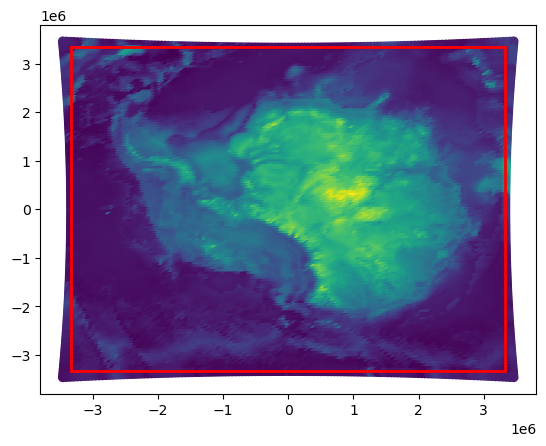

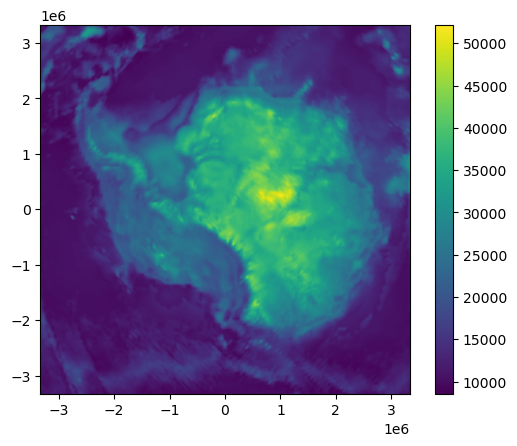

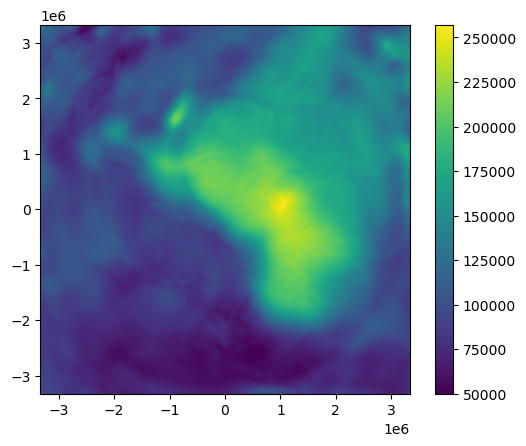

In [5]:
"""
load moho and lab data
"""

# moho
data_H_Moho = pd.read_csv(path_moho ,sep="\t",skiprows=3,header=None, names=["Lon","Lat","Moho"])
myProj = Proj("EPSG:3031")  # WGS 84 / Antarctic Polar StereographicEPSG:3031
x_moho, y_moho  = myProj(data_H_Moho.Lon, data_H_Moho.Lat)

rect = Rectangle((rect_x, rect_y), rect_width, rect_height, linewidth=2, edgecolor='r', facecolor='none') # draw rectangle around grid extent
sc = plt.scatter(x_moho, y_moho, c=data_H_Moho.Moho, cmap="viridis", marker="o")
plt.gca().add_patch(rect)
plt.show()

xi_moho, yi_moho = xi_topo, yi_topo
grid_moho = griddata((x_moho,y_moho),data_H_Moho.Moho,(xi_moho,yi_moho))*km


# lab
data_H_LAB = pd.read_csv(path_lab,sep="\t",skiprows=3,header=None, names=["Lon","Lat","LAB"])
x_lab, y_lab  = myProj(data_H_LAB.Lon, data_H_LAB.Lat)

xi_lab, yi_lab = xi_moho, yi_moho
grid_lab = griddata((x_lab,y_lab),data_H_LAB.LAB,(xi_lab,yi_lab))*km

plt.imshow(grid_moho, extent=[np.min(xi_moho), np.max(xi_moho), np.min(yi_moho), np.max(yi_moho)], cmap='viridis')
plt.colorbar()
plt.show()

plt.imshow(grid_lab, extent=[np.min(xi_lab), np.max(xi_lab), np.min(yi_lab), np.max(yi_lab)], cmap='viridis')
plt.colorbar()
plt.show()



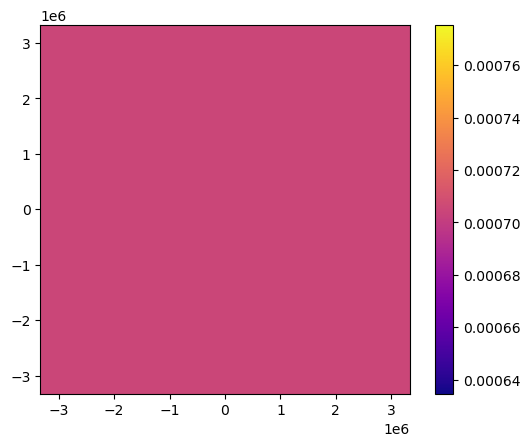

In [6]:
# # RHP

RHP = 0.000000705 # mitttelwert NEGIS

xi_A, yi_A = xi_moho, yi_moho
grid_A = griddata((x_moho,y_moho),np.ones(np.shape(data_H_LAB.LAB))*RHP,(xi_A,yi_A))*km
plt.imshow(grid_A, extent=[np.min(xi_topo), np.max(xi_topo), np.min(yi_topo), np.max(yi_topo)], cmap='plasma')
plt.colorbar()

In [7]:
"""
load in the simulated RHP data - not yet working
"""

# XX TODO - wheres the data?

# # Load data
file_path = "INPUT_DATA_DEMO/Predicted_HP_ANT.txt"
data_RHP = pd.read_csv(file_path,sep=" ",skiprows=0,header=None, names=["Lon","Lat","c","d","e"])

#plt.scatter(x_rhp, y_rhp) # sind also schon ein meshgrid oder??

# x_rhp, y_rhp = myProj(data_RHP.Lon.values, data_RHP.Lat.values)
# xi_rhp, yi_rhp = np.meshgrid(np.sort(x_rhp), np.sort(y_rhp))
# # #grid_rhp = griddata((x_rhp, y_rhp), data_RHP.RHP, (xi_rhp, yi_rhp), method="linear")
# grid_rhp = griddata((x_rhp, y_rhp), data_RHP.c, (xi_rhp, yi_rhp), method="nearest")

# plt.imshow(grid_rhp, extent=[np.min(xi_rhp), np.max(xi_rhp), np.min(yi_rhp), np.max(yi_rhp)], cmap='plasma')
# plt.colorbar()

In [8]:
data_calc,data_resolution = [[xi_topo,yi_topo,grid_topo]      ,[xi_moho,yi_moho,grid_moho],[xi_lab,yi_lab,grid_lab]], [grid_size_topo,grid_size_topo,grid_size_topo,grid_size_topo]

with open('output/data_input_ANT_noseds.pickle', 'wb') as handle:
        pickle.dump([data_calc,data_resolution], handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('output/RHP_data_input_ANT.pickle', 'wb') as handle:
        pickle.dump([xi_A,yi_A,grid_A], handle, protocol=pickle.HIGHEST_PROTOCOL)
